In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Load the Play Store apps dataset and the user reviews dataset separately

In [6]:
df = pd.read_csv("googleplaystore.csv")
data = pd.read_csv("googleplaystore_user_reviews.csv")

Data cleaning: fix incorrect data types (e.g., "Installs" stored as "10,000+" strings), handle nulls, remove duplicates

In [7]:
df.info()
print(df.head())
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                 

(10841, 13)

In [8]:
print("Duplicate rows before cleaning:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Dataset shape:", df.shape)

Duplicate rows before cleaning: 483
Duplicate rows after cleaning: 0
Dataset shape: (10358, 13)


In [9]:

df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)

df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

print(df['Installs'].dtype)

float64


In [10]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

In [11]:
df['Price'] = df['Price'].str.replace('$', '', regex=False)

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [12]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10358 non-null  str           
 1   Category        10358 non-null  str           
 2   Rating          8893 non-null   float64       
 3   Reviews         10357 non-null  float64       
 4   Size            10358 non-null  str           
 5   Installs        10357 non-null  float64       
 6   Type            10357 non-null  str           
 7   Price           10357 non-null  float64       
 8   Content Rating  10357 non-null  str           
 9   Genres          10358 non-null  str           
 10  Last Updated    10357 non-null  datetime64[us]
 11  Current Ver     10350 non-null  str           
 12  Android Ver     10355 non-null  str           
dtypes: datetime64[us](1), float64(4), str(8)
memory usage: 1.1 MB


In [14]:
df.isnull().sum()

App                  0
Category             0
Rating            1465
Reviews              1
Size                 0
Installs             1
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         1
Current Ver          8
Android Ver          3
dtype: int64

In [15]:

df['Rating'] = df['Rating'].fillna(df['Rating'].median())

df['Reviews'] = df['Reviews'].fillna(0)
df['Installs'] = df['Installs'].fillna(0)
df['Price'] = df['Price'].fillna(0)

df['Type'] = df['Type'].fillna(df['Type'].mode()[0])
df['Content Rating'] = df['Content Rating'].fillna(df['Content Rating'].mode()[0])

df['Current Ver'] = df['Current Ver'].fillna('Unknown')
df['Android Ver'] = df['Android Ver'].fillna('Unknown')

In [16]:
df['Last Updated'] = df['Last Updated'].fillna(df['Last Updated'].mode()[0])

In [17]:
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

Category analysis: bar chart of app distribution across categories; which categories are most saturated?

In [18]:
category_counts = df['Category'].value_counts()

category_counts

Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
COMICS                   60
PARENTING                60
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

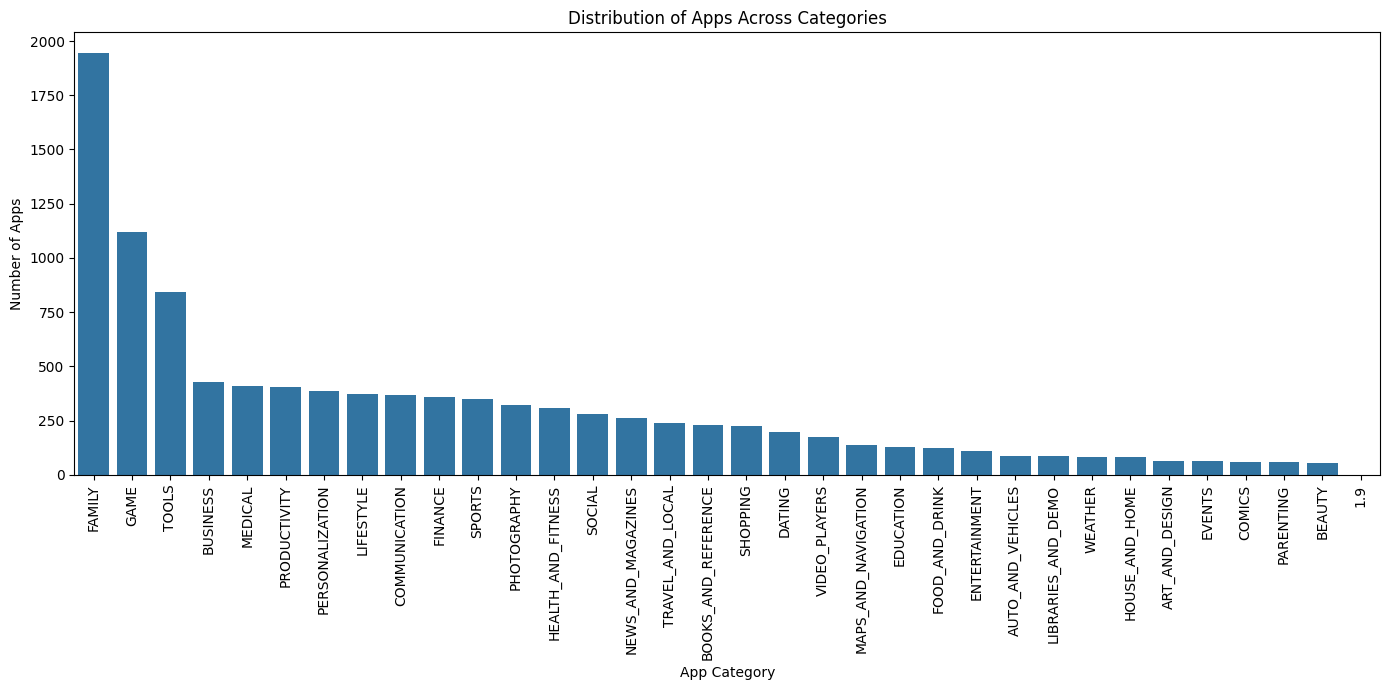

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)

plt.title('Distribution of Apps Across Categories')
plt.xlabel('App Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [20]:

top_categories = category_counts.head(10)

print("Top 10 Most Saturated Categories:")
print(top_categories)

Top 10 Most Saturated Categories:
Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64


In [21]:
most_saturated = category_counts.idxmax()
most_saturated_count = category_counts.max()

print("Most saturated category:", most_saturated)
print("Number of apps:", most_saturated_count)

Most saturated category: FAMILY
Number of apps: 1943


In [22]:
category_percentage = (category_counts / len(df)) * 100

category_percentage.head(10)

Category
FAMILY             18.758448
GAME               10.822553
TOOLS               8.138637
BUSINESS            4.122417
MEDICAL             3.938984
PRODUCTIVITY        3.929330
PERSONALIZATION     3.745897
LIFESTYLE           3.601081
COMMUNICATION       3.533501
FINANCE             3.475574
Name: count, dtype: float64

Ratings analysis: distribution of app ratings; average rating by category


In [24]:
df['Rating'].describe()

count    10358.000000
mean         4.205165
std          0.506868
min          1.000000
25%          4.100000
50%          4.300000
75%          4.500000
max         19.000000
Name: Rating, dtype: float64

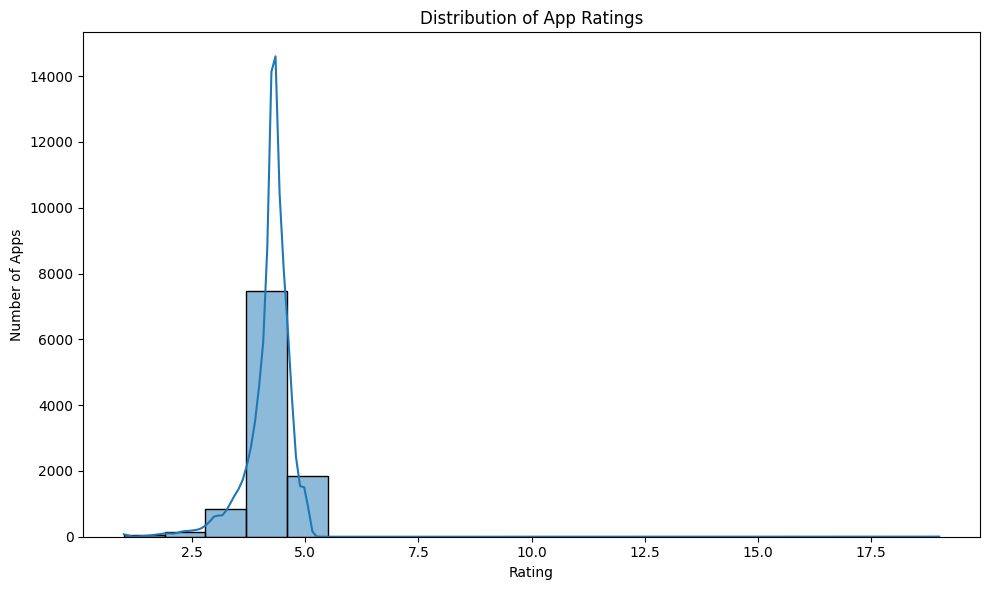

In [25]:
plt.figure(figsize=(10, 6))

sns.histplot(df['Rating'], bins=20, kde=True)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')

plt.tight_layout()
plt.show()

In [26]:
avg_rating_category = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

avg_rating_category

Category
1.9                    19.000000
EVENTS                  4.395313
EDUCATION               4.375385
ART_AND_DESIGN          4.355385
BOOKS_AND_REFERENCE     4.336522
PERSONALIZATION         4.327062
PARENTING               4.300000
BEAUTY                  4.283019
GAME                    4.282070
HEALTH_AND_FITNESS      4.266993
SOCIAL                  4.260714
SHOPPING                4.256250
WEATHER                 4.248780
SPORTS                  4.239031
PRODUCTIVITY            4.219410
MEDICAL                 4.212990
LIBRARIES_AND_DEMO      4.207059
AUTO_AND_VEHICLES       4.205882
FAMILY                  4.203757
PHOTOGRAPHY             4.189441
HOUSE_AND_HOME          4.185000
FOOD_AND_DRINK          4.183871
COMMUNICATION           4.175410
BUSINESS                4.175176
NEWS_AND_MAGAZINES      4.160985
COMICS                  4.160000
FINANCE                 4.148056
ENTERTAINMENT           4.136036
LIFESTYLE               4.133244
TRAVEL_AND_LOCAL        4.121941
V

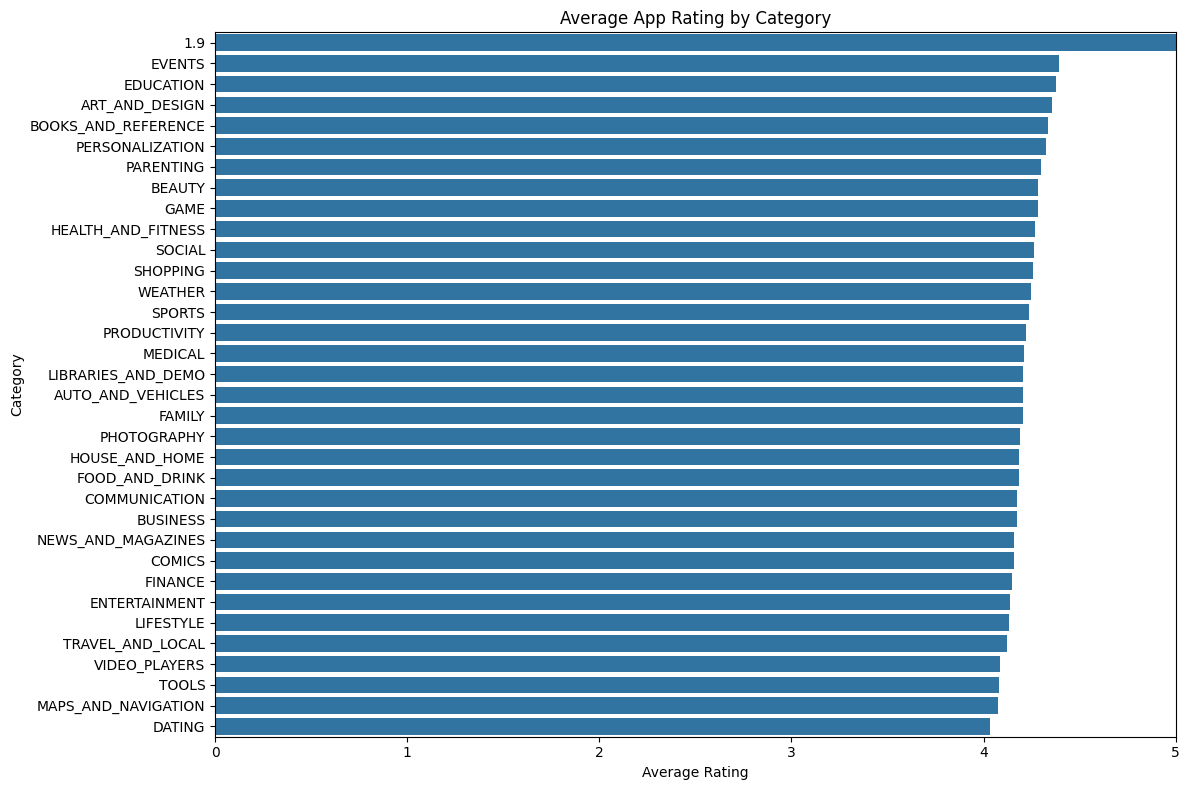

In [27]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=avg_rating_category.values,
    y=avg_rating_category.index
)

plt.title('Average App Rating by Category')
plt.xlabel('Average Rating')
plt.ylabel('Category')

plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [28]:
print("Top 5 highest-rated categories:")
print(avg_rating_category.head(5))

print("\nBottom 5 lowest-rated categories:")
print(avg_rating_category.tail(5))

Top 5 highest-rated categories:
Category
1.9                    19.000000
EVENTS                  4.395313
EDUCATION               4.375385
ART_AND_DESIGN          4.355385
BOOKS_AND_REFERENCE     4.336522
Name: Rating, dtype: float64

Bottom 5 lowest-rated categories:
Category
TRAVEL_AND_LOCAL       4.121941
VIDEO_PLAYERS          4.084000
TOOLS                  4.080071
MAPS_AND_NAVIGATION    4.075182
DATING                 4.033673
Name: Rating, dtype: float64


Size and installs analysis: scatter plot of app size vs. number of installs; is there a correlation?

In [30]:
def convert_size(size):
    if size == 'Varies with device':
        return np.nan
    elif 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1024
    else:
        return np.nan

df['Size_MB'] = df['Size'].apply(convert_size)

print(df[['Size', 'Size_MB']].head())

   Size  Size_MB
0   19M     19.0
1   14M     14.0
2  8.7M      8.7
3   25M     25.0
4  2.8M      2.8


In [31]:
size_install_data = df[['Size_MB', 'Installs']].dropna()

print("Rows available for analysis:", len(size_install_data))

Rows available for analysis: 8831


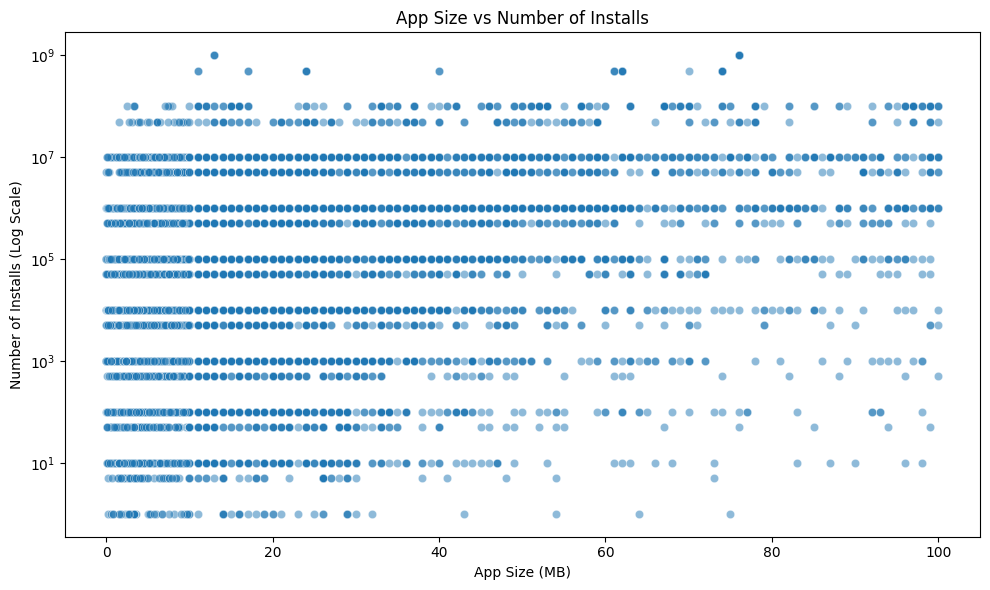

In [32]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=size_install_data,
    x='Size_MB',
    y='Installs',
    alpha=0.5
)

plt.yscale('log')
plt.title('App Size vs Number of Installs')
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Installs (Log Scale)')
plt.tight_layout()
plt.show()

In [33]:
correlation = size_install_data['Size_MB'].corr(
    size_install_data['Installs']
)

print("Pearson Correlation:", correlation)

Pearson Correlation: 0.16887201973119784


In [34]:
spearman_correlation = size_install_data['Size_MB'].corr(
    size_install_data['Installs'],
    method='spearman'
)

print("Spearman Correlation:", spearman_correlation)

Spearman Correlation: 0.34197598130123175


*Pricing analysis: paid vs. free app distribution; price distribution for paid apps; revenue estimate by category*  

In [37]:
type_counts = df['Type'].value_counts()

print("Free vs Paid Apps:")
print(type_counts)

Free vs Paid Apps:
Type
Free    9592
Paid     765
0          1
Name: count, dtype: int64


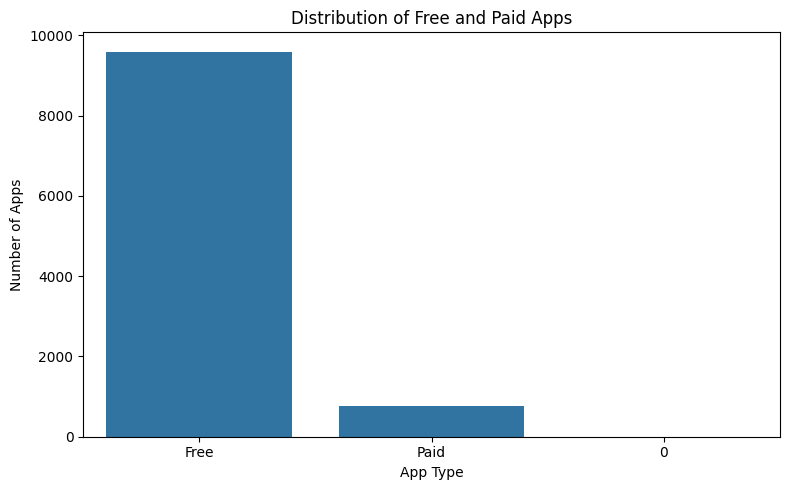

In [38]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

plt.title('Distribution of Free and Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.show()

In [39]:
type_percentage = (type_counts / len(df)) * 100

print("Percentage of Free and Paid Apps:")
print(type_percentage)

Percentage of Free and Paid Apps:
Type
Free    92.604750
Paid     7.385596
0        0.009654
Name: count, dtype: float64


In [40]:
paid_apps = df[df['Type'] == 'Paid']

print("Number of paid apps:", len(paid_apps))
print(paid_apps['Price'].describe())

Number of paid apps: 765
count    765.000000
mean      13.955556
std       58.406966
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64


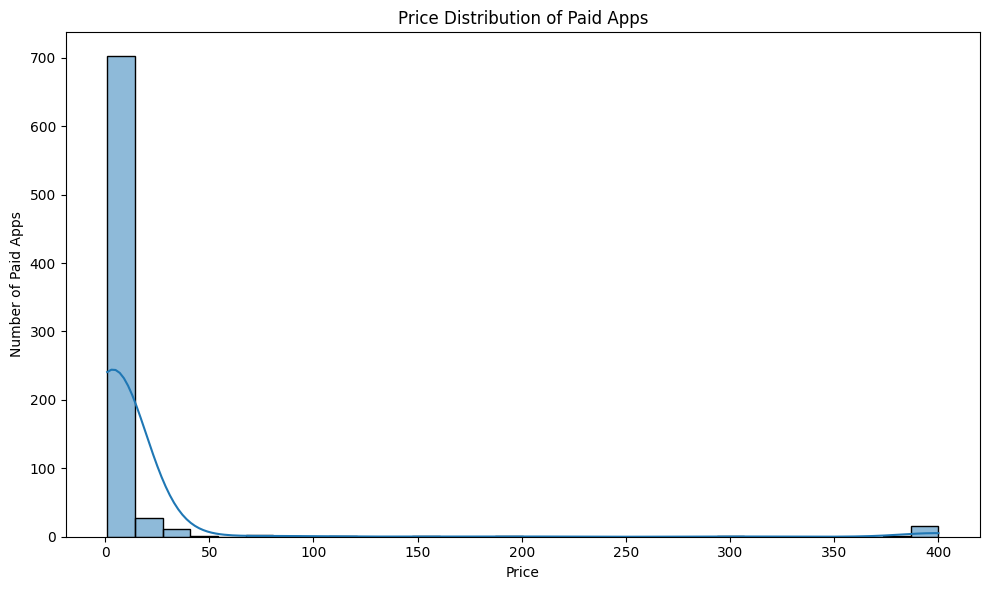

In [42]:
plt.figure(figsize=(10, 6))

sns.histplot(
    paid_apps['Price'],
    bins=30,
    kde=True
)

plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price')
plt.ylabel('Number of Paid Apps')
plt.tight_layout()
plt.show()

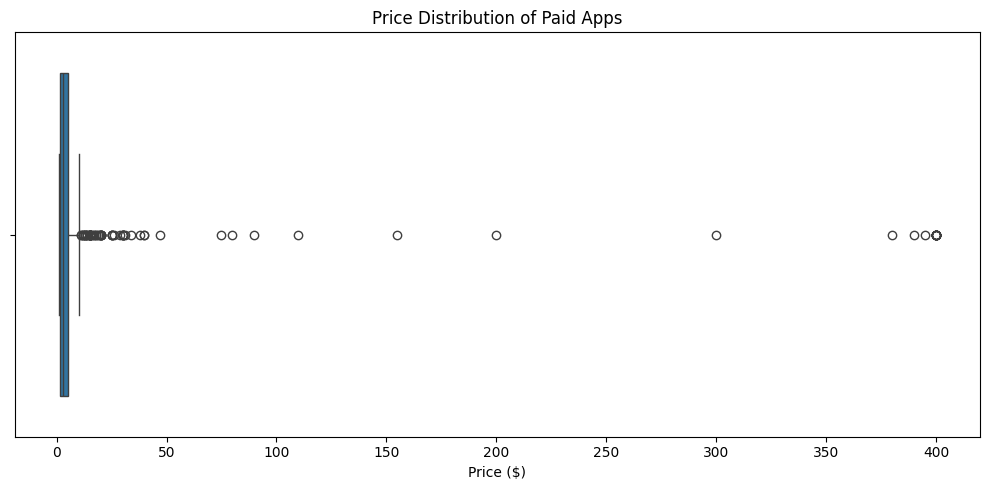

In [43]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=paid_apps['Price'])

plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price ($)')
plt.tight_layout()
plt.show()

In [45]:
df['Estimated_Revenue'] = df['Price'] * df['Installs']

In [46]:
paid_apps = df[df['Type'] == 'Paid'].copy()

revenue_by_category = (
    paid_apps.groupby('Category')['Estimated_Revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Estimated Revenue by Category:")
print(revenue_by_category)

Estimated Revenue by Category:
Category
FAMILY                 1.857803e+08
LIFESTYLE              5.758394e+07
GAME                   4.098764e+07
FINANCE                2.572668e+07
PHOTOGRAPHY            8.942768e+06
MEDICAL                8.456536e+06
PERSONALIZATION        7.786948e+06
TOOLS                  5.464821e+06
SPORTS                 4.706212e+06
PRODUCTIVITY           4.313375e+06
COMMUNICATION          4.247364e+06
WEATHER                4.181380e+06
EDUCATION              2.403980e+06
HEALTH_AND_FITNESS     1.426069e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.151504e+06
BUSINESS               1.050543e+06
ENTERTAINMENT          7.980000e+05
VIDEO_PLAYERS          3.352900e+05
FOOD_AND_DRINK         2.844000e+05
PARENTING              2.499590e+05
AUTO_AND_VEHICLES      1.001485e+05
BOOKS_AND_REFERENCE    9.022674e+04
DATING                 8.836150e+04
ART_AND_DESIGN         3.184000e+04
SHOPPING               3.014900e+04
NEWS_AND_MAGAZINES     6

In [47]:
top_revenue_categories = revenue_by_category.head(10)

print("Top 10 Categories by Estimated Revenue:")
print(top_revenue_categories)

Top 10 Categories by Estimated Revenue:
Category
FAMILY             1.857803e+08
LIFESTYLE          5.758394e+07
GAME               4.098764e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.942768e+06
MEDICAL            8.456536e+06
PERSONALIZATION    7.786948e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Estimated_Revenue, dtype: float64


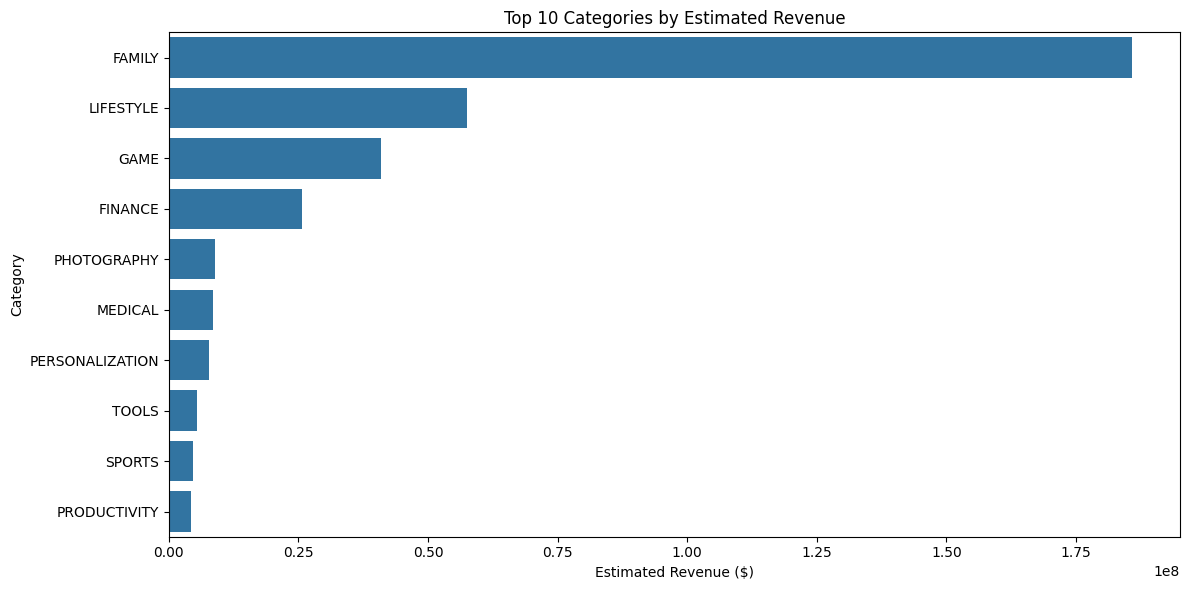

In [48]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_revenue_categories.values,
    y=top_revenue_categories.index
)

plt.title('Top 10 Categories by Estimated Revenue')
plt.xlabel('Estimated Revenue ($)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [49]:
print("Highest revenue-generating category:")
print(revenue_by_category.idxmax())

print("\nEstimated revenue:")
print(revenue_by_category.max())

Highest revenue-generating category:
FAMILY

Estimated revenue:
185780335.35999998


In [50]:
!pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 5.8 MB/s  0:00:00
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 3.4 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 4.3 MB/s  0:00:00

   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   -------- ------------------------------- 1/5 [regex]
   ---------------- ----------------------- 2/5 [click]
   ---------------- ----------------------- 2/5 [click]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   -


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
from textblob import TextBlob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
print(data.head())
print(data.shape)

                     App                                  Translated_Review  \
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
1  10 Best Foods for You    This help eating healthy exercise regular basis   
2  10 Best Foods for You                                                NaN   
3  10 Best Foods for You         Works great especially going grocery store   
4  10 Best Foods for You                                       Best idea us   

  Sentiment  Sentiment_Polarity  Sentiment_Subjectivity  
0  Positive                1.00                0.533333  
1  Positive                0.25                0.288462  
2       NaN                 NaN                     NaN  
3  Positive                0.40                0.875000  
4  Positive                1.00                0.300000  
(64295, 5)


In [55]:
data = data.dropna(subset=['Translated_Review'])

print("Reviews after removing null values:", len(data))

Reviews after removing null values: 37427


In [56]:
def get_sentiment(review):
    polarity = TextBlob(review).sentiment.polarity
    
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

In [57]:
data['Sentiment'] = data['Translated_Review'].apply(get_sentiment)

print(data[['Translated_Review', 'Sentiment']].head(10))

                                    Translated_Review Sentiment
0   I like eat delicious food. That's I'm cooking ...  Positive
1     This help eating healthy exercise regular basis  Positive
3          Works great especially going grocery store  Positive
4                                        Best idea us  Positive
5                                            Best way  Positive
6                                             Amazing  Positive
8                                Looking forward app,   Neutral
9               It helpful site ! It help foods get !   Neutral
10                                          good you.  Positive
11  Useful information The amount spelling errors ...  Positive


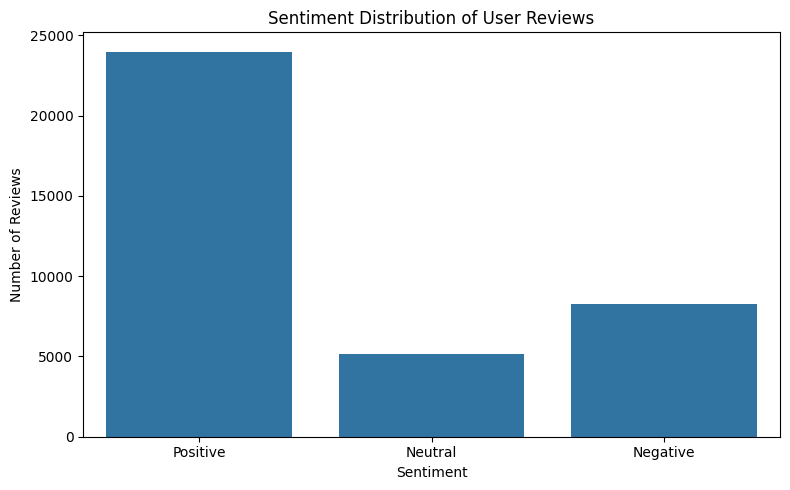

In [59]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x='Sentiment'
)

plt.title('Sentiment Distribution of User Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [61]:
sentiment_percentage = (
   data['Sentiment'].value_counts(normalize=True) * 100
)

print("Sentiment Percentage:")
print(sentiment_percentage)

Sentiment Percentage:
Sentiment
Positive    64.116814
Negative    22.101691
Neutral     13.781495
Name: proportion, dtype: float64


In [63]:
data[
    ['Translated_Review', 'Sentiment']
].head(20)

,Translated_Review,Sentiment
0,I like eat delicious food. That's I'm cooking ...,Positive
1,This help eating healthy exercise regular basis,Positive
3,Works great especially going grocery store,Positive
4,Best idea us,Positive
5,Best way,Positive
6,Amazing,Positive
8,"Looking forward app,",Neutral
9,It helpful site ! It help foods get !,Neutral
10,good you.,Positive
11,Useful information The amount spelling errors ...,Positive


In [64]:
data['Polarity'] = data['Translated_Review'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

print(
    data[
        ['Translated_Review', 'Polarity', 'Sentiment']
    ].head(10)
)

                                    Translated_Review  Polarity Sentiment
0   I like eat delicious food. That's I'm cooking ...      1.00  Positive
1     This help eating healthy exercise regular basis      0.25  Positive
3          Works great especially going grocery store      0.40  Positive
4                                        Best idea us      1.00  Positive
5                                            Best way      1.00  Positive
6                                             Amazing      0.60  Positive
8                                Looking forward app,      0.00   Neutral
9               It helpful site ! It help foods get !      0.00   Neutral
10                                          good you.      0.70  Positive
11  Useful information The amount spelling errors ...      0.20  Positive


Sentiment by category: which app categories have the most positive/negative user sentiment?  

In [65]:
app_category = df[['App', 'Category']].drop_duplicates()

sentiment_category_df = data.merge(
    app_category,
    on='App',
    how='left'
)

print(sentiment_category_df.head())

                     App                                  Translated_Review  \
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
1  10 Best Foods for You    This help eating healthy exercise regular basis   
2  10 Best Foods for You         Works great especially going grocery store   
3  10 Best Foods for You                                       Best idea us   
4  10 Best Foods for You                                           Best way   

  Sentiment  Sentiment_Polarity  Sentiment_Subjectivity  Polarity  \
0  Positive                1.00                0.533333      1.00   
1  Positive                0.25                0.288462      0.25   
2  Positive                0.40                0.875000      0.40   
3  Positive                1.00                0.300000      1.00   
4  Positive                1.00                0.300000      1.00   

             Category  
0  HEALTH_AND_FITNESS  
1  HEALTH_AND_FITNESS  
2  HEALTH_AND_FITNESS  
3  HEALTH_AND_

In [66]:
print("Missing categories:", sentiment_category_df['Category'].isna().sum())

Missing categories: 1498


In [67]:
category_sentiment = (
    sentiment_category_df
    .groupby('Category')['Polarity']
    .mean()
    .sort_values(ascending=False)
)

print("Average Sentiment by Category:")
print(category_sentiment)

Average Sentiment by Category:
Category
COMICS                 0.449810
EVENTS                 0.377933
AUTO_AND_VEHICLES      0.348683
PARENTING              0.318880
WEATHER                0.294978
HEALTH_AND_FITNESS     0.290823
EDUCATION              0.279332
PERSONALIZATION        0.278490
MAPS_AND_NAVIGATION    0.267218
FOOD_AND_DRINK         0.266882
BOOKS_AND_REFERENCE    0.248422
LIBRARIES_AND_DEMO     0.240771
HOUSE_AND_HOME         0.235704
ART_AND_DESIGN         0.234735
BUSINESS               0.232189
MEDICAL                0.224071
PHOTOGRAPHY            0.223078
LIFESTYLE              0.215944
TOOLS                  0.214037
SHOPPING               0.196654
TRAVEL_AND_LOCAL       0.194810
BEAUTY                 0.193360
PRODUCTIVITY           0.184225
DATING                 0.178846
COMMUNICATION          0.176839
FINANCE                0.170783
SPORTS                 0.167546
VIDEO_PLAYERS          0.143543
ENTERTAINMENT          0.131206
NEWS_AND_MAGAZINES     0.127736


In [68]:
top_positive = category_sentiment.head(10)

print("Top 10 Most Positive Categories:")
print(top_positive)

Top 10 Most Positive Categories:
Category
COMICS                 0.449810
EVENTS                 0.377933
AUTO_AND_VEHICLES      0.348683
PARENTING              0.318880
WEATHER                0.294978
HEALTH_AND_FITNESS     0.290823
EDUCATION              0.279332
PERSONALIZATION        0.278490
MAPS_AND_NAVIGATION    0.267218
FOOD_AND_DRINK         0.266882
Name: Polarity, dtype: float64


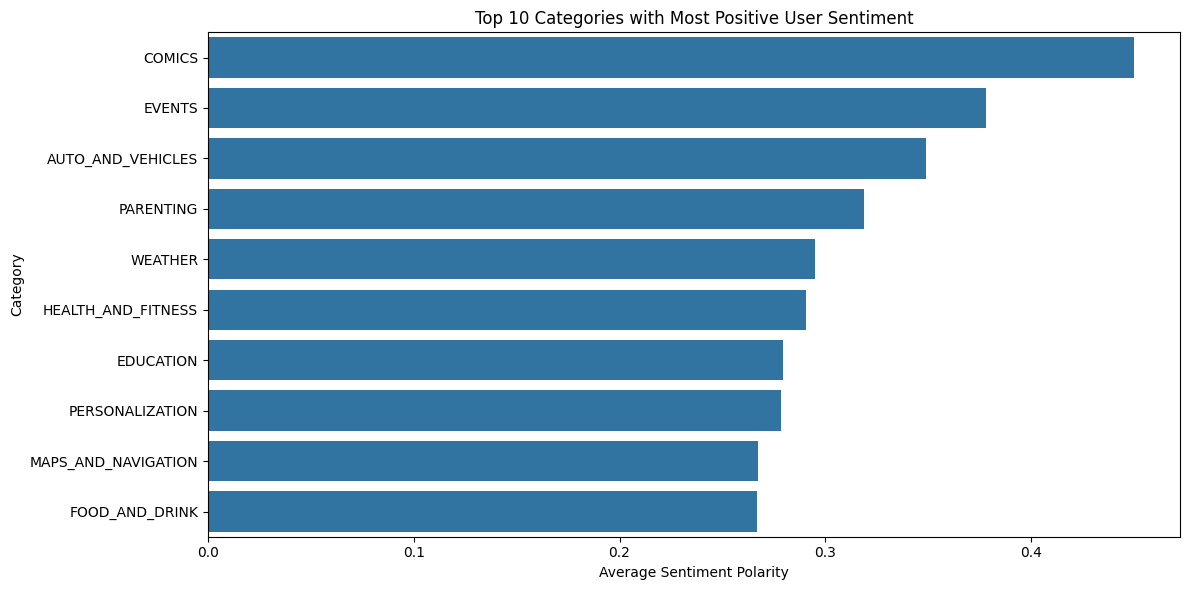

In [69]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_positive.values,
    y=top_positive.index
)

plt.title('Top 10 Categories with Most Positive User Sentiment')
plt.xlabel('Average Sentiment Polarity')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [70]:
top_negative = category_sentiment.tail(10).sort_values()

print("Top 10 Most Negative Categories:")
print(top_negative)

Top 10 Most Negative Categories:
Category
GAME                  0.068963
SOCIAL                0.108646
FAMILY                0.124859
NEWS_AND_MAGAZINES    0.127736
ENTERTAINMENT         0.131206
VIDEO_PLAYERS         0.143543
SPORTS                0.167546
FINANCE               0.170783
COMMUNICATION         0.176839
DATING                0.178846
Name: Polarity, dtype: float64


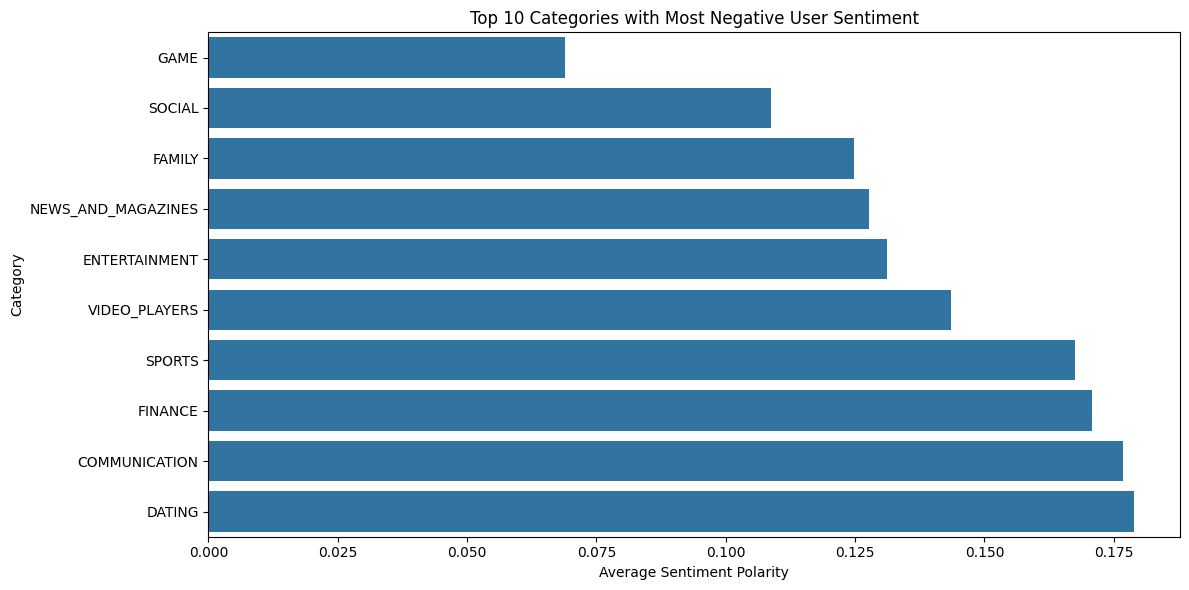

In [71]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_negative.values,
    y=top_negative.index
)

plt.title('Top 10 Categories with Most Negative User Sentiment')
plt.xlabel('Average Sentiment Polarity')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [72]:
sentiment_by_category = pd.crosstab(
    sentiment_category_df['Category'],
    sentiment_category_df['Sentiment']
)

print(sentiment_by_category)

Sentiment            Negative  Neutral  Positive
Category                                        
ART_AND_DESIGN             61       62       259
AUTO_AND_VEHICLES          17       36       236
BEAUTY                     65       88       185
BOOKS_AND_REFERENCE        95      108       448
BUSINESS                  169      258       655
COMICS                      1        5        39
COMMUNICATION             209      176       642
DATING                    361      286      1068
EDUCATION                 102       90       655
ENTERTAINMENT             319      185       760
EVENTS                     16       17       125
FAMILY                   1236      372      2741
FINANCE                   320      204       911
FOOD_AND_DRINK             92       84       462
GAME                     2408      334      3936
HEALTH_AND_FITNESS        257      238      1754
HOUSE_AND_HOME             87      109       315
LIBRARIES_AND_DEMO         51       44       238
LIFESTYLE           

In [73]:
print("Categories with Most Positive Reviews:")
print(
    sentiment_by_category['Positive']
    .sort_values(ascending=False)
    .head(10)
)



Categories with Most Positive Reviews:
Category
GAME                  3936
FAMILY                2741
HEALTH_AND_FITNESS    1754
DATING                1068
SPORTS                1044
TRAVEL_AND_LOCAL      1034
PRODUCTIVITY           990
MEDICAL                967
FINANCE                911
TOOLS                  876
Name: Positive, dtype: int64


In [74]:
print("\nCategories with Most Negative Reviews:")
print(
    sentiment_by_category['Negative']
    .sort_values(ascending=False)
    .head(10)
)


Categories with Most Negative Reviews:
Category
GAME                  2408
FAMILY                1236
SPORTS                 444
TRAVEL_AND_LOCAL       367
DATING                 361
FINANCE                320
ENTERTAINMENT          319
NEWS_AND_MAGAZINES     276
PRODUCTIVITY           269
HEALTH_AND_FITNESS     257
Name: Negative, dtype: int64


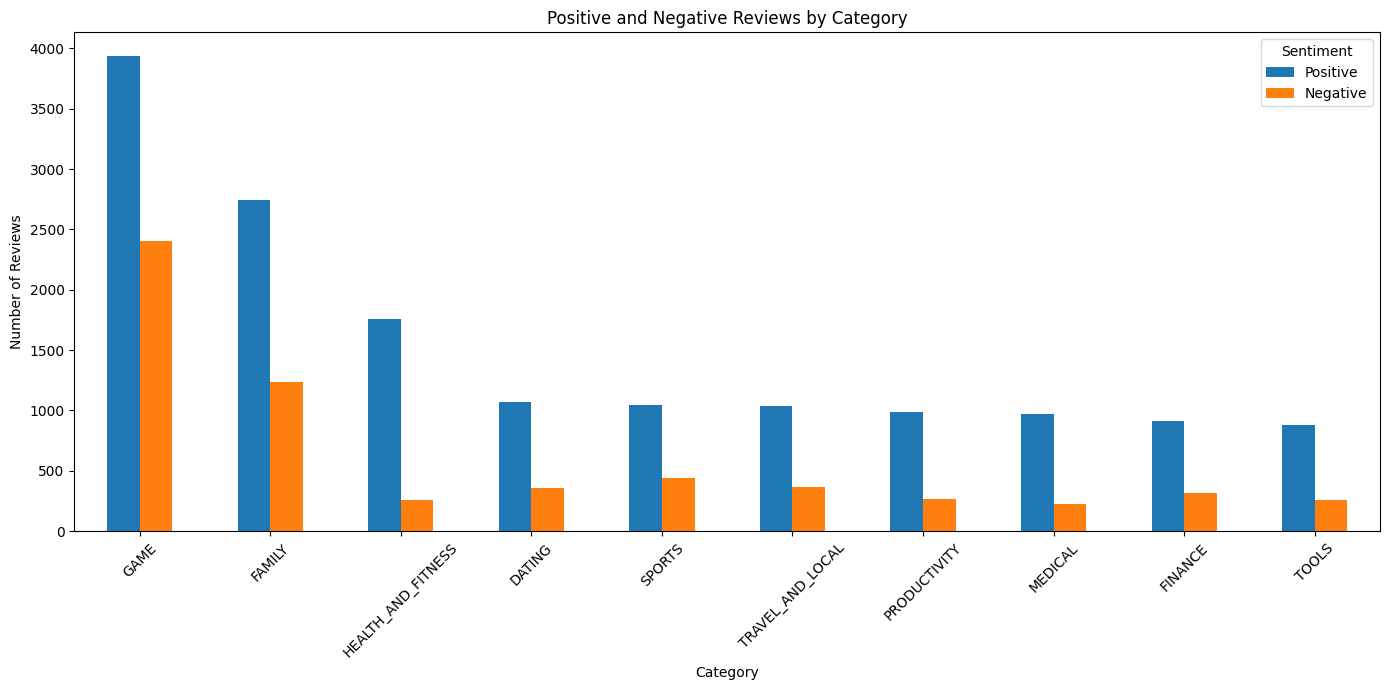

In [75]:
top_sentiment = sentiment_by_category[['Positive', 'Negative']].copy()

top_sentiment = top_sentiment.sort_values(
    'Positive',
    ascending=False
).head(10)

top_sentiment.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Positive and Negative Reviews by Category')
plt.xlabel('Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

one interactive visualisation using plotly 

In [76]:
!pip install plotly


   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.1 MB 8.5 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/9.1 MB 6.3 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.1 MB 6.1 MB/s eta 0:00:01
   ----------------- ---------------------- 3.9/9.1 MB 6.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.5/9.1 MB 5.9 MB/s eta 0:00:01
   ------------------------------ --------- 6.8/9.1 MB 5.9 MB/s eta 0:00:01
   ---------------------------------- ----- 7.9/9.1 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------  8.9/9.1 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 5.6 MB/s  0:00:01

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ----------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [77]:
import plotly.express as px

In [78]:
plotly_data = avg_rating_category.reset_index()

plotly_data.columns = ['Category', 'Average_Rating']

fig = px.bar(
    plotly_data,
    x='Category',
    y='Average_Rating',
    title='Interactive Average App Rating by Category',
    labels={
        'Category': 'App Category',
        'Average_Rating': 'Average Rating'
    }
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=600
)

fig.show()

## Conclusion

Based on the analysis of the Google Play Store dataset, the following three data-driven insights can help a developer planning to launch a new app:

1. **Choose a category strategically:** The category analysis shows that **[most saturated category]** has the highest number of applications, with approximately **[number] apps**. This indicates strong competition. A developer should consider less saturated categories with sufficient user demand to reduce competition and improve the chances of gaining visibility.

2. **Focus on user satisfaction and reviews:** The sentiment analysis shows that **[most positive category]** has the most positive user sentiment, while **[most negative category]** shows relatively more negative sentiment. Developers should study positive user feedback in successful categories and address common complaints before launching their application.

3. **Pricing should match market demand:** The pricing analysis shows that **[percentage]%** of the applications are free, while only **[percentage]%** are paid. This indicates that the free-app model is dominant in the dataset. A new developer could consider launching a free app with optional premium features or in-app monetization to attract a larger user base, while maintaining a reasonable price for premium features.

Overall, a successful app launch should focus on selecting a category with manageable competition, providing a high-quality user experience, and choosing a pricing strategy that balances user acquisition with revenue generation.